In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib as mpl
import tensorflow.random as tf_r
import keras_tuner
import keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten #, Reshape
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from keras import Input
from scipy.optimize import curve_fit
import time
import BuildModel as BM
import pickle

plt.rcParams['font.size'] = 14

np.random.seed(12345)
tf_r.set_seed(12345)

I0000 00:00:1779346543.741395  766568 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779346543.789883  766568 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779346544.963720  766568 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [6]:
np.random.seed(12345)

jump = lambda drift1, drift2, std1, std2: [int(np.random.normal(drift1,std1)), int(np.random.normal(drift2, std2))]

def pattern(i,z1,z2,a1,a2):
    return [int(a1*np.sin((np.pi*i)/z1)), int(a2*np.sin((np.pi*i)/z2))]

In [9]:
SNRs = [ 1, 3, 10]

# training set size and time series
N=10000
L=60
n_class = 3
# noise bias 
bias = 5 

#duration of the pattern
d = 11
# since i want to test the effectiveness of SNR as a measure classifiability 
# i start by seeing if different training sets (different amplitude and time)
# but with same SNR give more or less the same result: similar accuracy after
# a fixed number of epochs
pattern_params = []
sigma_list = [10, 20 , 40, 60]


for SNR in SNRs:
    SNR_partition = np.linspace(0, 1, 5)
    for s in SNR_partition:
        for sigma in sigma_list:
            A_1 = (2*(np.pi + 4)*d*SNR*s / np.pi**3)**0.5 * sigma
            A_2 = (2*(np.pi + 4)*d*SNR*(1-s) / np.pi**3)**0.5 * sigma
            #mu_1, mu_2 = np.random.randint(0, 100, 2)
            for _ in range(5):
                pattern_params.append( (A_1, sigma, bias, A_2, sigma, bias) ) 

    
    
# run only to generate data
y = np.zeros(N) # 1D (same label)
x = np.zeros((N,L))
acc = []

BATCH_SIZE = 200
EPOCHS = 100


for params in pattern_params:
    start = time.time()
    y = np.zeros(N) # 1D (same label)
    x = np.zeros((N,L,2))
    Z1 = Z2 = d
   
    A1, DX1, bias1, A2, DX2, bias2 = params 
    for i in range(N):
            if i>0: 
                jump0, jump1 = jump(bias1, bias2, DX1, DX2)
                x[i][0][0] = x[i-1][-1][0] + jump0 
                x[i][0][1] = x[i-1][-1][1] + jump1
            
            for j in range(1,L):
                jump0, jump1 = jump(bias1, bias2, DX1, DX2)
                x[i][j][0] = x[i][j-1][0] + jump0
                x[i][j][1] = x[i][j-1][1] + jump1
                
            y[i] = i%3 # assign class labels (0,1,2,3,4,5,6)
                   
            if y[i]>0:
                # 0 -> 0 0
                if y[i]<3:
                    j01, j02 = np.random.randint(0,L-1-d, 2) 
                    sign = 3-2*y[i] 
                    
                    
                    for j in range(d): 
                       p_val1, p_val2 = pattern(j, d, d, A1, A2)
        
                       x[i][j01 + j][0] += sign * p_val1 # Canale 0
                       x[i][j02 + j][1] += sign * p_val2 # Canale 1
        
                    # 1 -> + +
                    # 2 -> - -
                """elif y[i]<5:
                    j01 = np.random.randint(0,L-1-Z1) 
                    j02 = np.random.randint(0,L-1-Z2) 
                    sign = 3-2*(y[i]-2)
                    for j in range(Z1):
                        x[i][j01+j][0] += pattern(j,Z1,Z2,A1,A2)[0]
                    for j in range(Z2):
                        x[i][j02+j][1] += sign*pattern(j,Z1,Z2,A1,A2)[1]
                    # 3 -> + +
                    # 4 -> + -
                else:
                    j01 = np.random.randint(0,L-1-Z1) 
                    j02 = np.random.randint(0,L-1-Z2) 
                    for j in range(Z1):
                        x[i][j01+j][0] += pattern(j,Z1,Z2,A1,A2)[0]
                    for j in range(Z2):
                        x[i][j02+j][1] += sign*pattern(j,Z1,Z2,A1,A2)[1]
                    # 5 -> - -
      
                  """
    #Show_data2D(x)
    model = BM.build_model(L, n_class=n_class)

    categ = y
    y = np.zeros((N,n_class))
    for i in range(N):
        y[i][int(categ[i])] = 1. # y contains one-hot encoding


    perc_train=0.8
    N_train = int(perc_train*N)
    x_train = x[:N_train]
    
    y_train = y[:N_train]
    x_val = x[N_train:]
    y_val = y[N_train:]
    N_val = len(x_val)
    
     
    #remove average value of each sample from its values
    xm_train = x_train.mean(axis=1)
    std_train = x_train.std(axis=1)
    xm_val = x_val.mean(axis=1)
    std_val = x_val.std(axis=1)
    # rescale with variance on the training set
    for i in range(N_train):
         x_train[i] = (x_train[i]-xm_train[i])/ std_train.mean(axis=0)
    for i in range(N_val):
        x_val[i] = (x_val[i]-xm_val[i])/ std_val.mean(axis=0)

    x_train = x_train.reshape(x_train.shape[0], L, 2)
    x_val =  x_val.reshape(x_val.shape[0], L, 2)
    
    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=15,
        restore_best_weights=True
    )
    
    fit = model.fit(x_train, y_train,
                    batch_size=BATCH_SIZE,
                    epochs=EPOCHS,
                    validation_data=(x_val, y_val),
                    verbose=False,
                    shuffle=True,
                    callbacks=[early_stop])
    
    # Prendi il MASSIMO, non l'ultimo
    acc.append(max(fit.history['val_accuracy']))
    stop = time.time()
        
    print(f"Done for {params[0]}, {params[1]}, {max(fit.history['val_accuracy'])}, {stop-start}")
    


Done for 0.0, 10, 0.4074999988079071, 17.661840677261353
Done for 0.0, 10, 0.4194999933242798, 29.63050866127014
Done for 0.0, 10, 0.3490000069141388, 8.655709505081177
Done for 0.0, 10, 0.34599998593330383, 8.0753653049469
Done for 0.0, 10, 0.36550000309944153, 7.983710765838623
Done for 0.0, 20, 0.4059999883174896, 17.714717388153076
Done for 0.0, 20, 0.4169999957084656, 17.35816264152527
Done for 0.0, 20, 0.41999998688697815, 21.19637966156006
Done for 0.0, 20, 0.39899998903274536, 14.681329488754272
Done for 0.0, 20, 0.414000004529953, 14.92090129852295
Done for 0.0, 40, 0.41350001096725464, 13.676780939102173
Done for 0.0, 40, 0.41100001335144043, 19.376049995422363
Done for 0.0, 40, 0.4230000078678131, 12.269592046737671
Done for 0.0, 40, 0.414000004529953, 15.133769750595093
Done for 0.0, 40, 0.4090000092983246, 15.370564222335815
Done for 0.0, 60, 0.398499995470047, 9.989979267120361
Done for 0.0, 60, 0.38850000500679016, 9.235875844955444
Done for 0.0, 60, 0.39250001311302185,

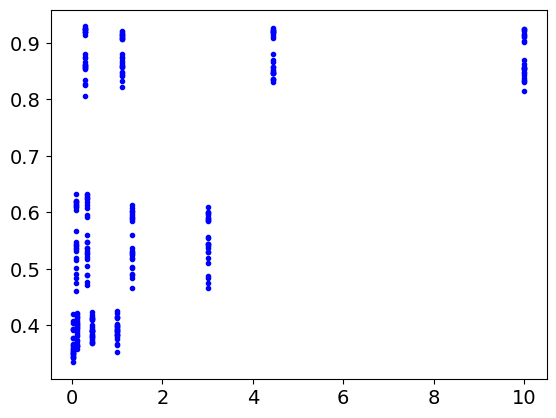

In [11]:
pattern_params = np.array(pattern_params)

# Now your calculation will work perfectly
snr_g = np.pi**3 / (2 * (np.pi + 4) * d * sigma**2) * (pattern_params[:, 0]**2 + pattern_params[:, 3]**2)

plt.plot(snr_g, accuracy_2D, "b.")

In [5]:

with open("accuracy_2D.pkl", "rb") as f:
    accuracy_2D = pickle.load(f)
accuracy_reshaped = np.reshape(accuracy_2D, (accuracy_2D.shape[0]//5, 5))
accuracy_mean = np.mean(accuracy_reshaped, axis=1)
accuracy_std = np.std(accuracy_reshaped, axis=1)

In [6]:
accuracy_fixed_SNR_partition = np.reshape(accuracy_mean, (accuracy_mean.shape[0]//4, 4))
fixed_SNR_partition_mean = np.mean(accuracy_fixed_SNR_partition, axis=1)
fixed_SNR_partition_std = np.std(accuracy_fixed_SNR_partition, axis=1)

In [7]:
chi = 0
for g in range(len(fixed_SNR_partition_mean)):
    chi_group = 0
    for i in range(4):
        chi += (accuracy_mean[g*4 + i] - fixed_SNR_partition_mean[g])**2/(accuracy_std[g*4 + i]**2 )
        chi_group += (accuracy_mean[g*4 + i] - fixed_SNR_partition_mean[g])**2/(accuracy_std[g*4 + i]**2)
    print(chi_group)

print(accuracy_reshaped.shape[0]-fixed_SNR_partition_mean.shape[0], chi)

11.703068113595387
15.316732207723497
1.305231153331235
1.0750114233769466
4.355578539337319
9.574681040753156
4.683324190191323
0.06097672458826765
0.16046440687228203
5.276970683317801
1.5589581235434804
2.1297228944432893
0.6825943910567822
2.4855055206467904
4.486571619884094
45 64.85539103266164


NameError: name 'label' is not defined

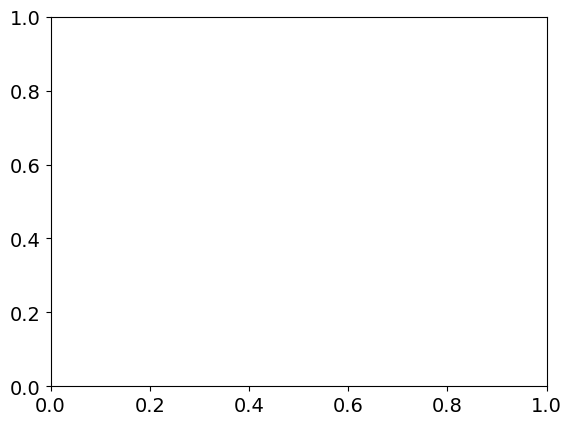

In [9]:
accuracy_fixed_snr = np.reshape(fixed_SNR_partition_mean, (fixed_SNR_partition_mean.shape[0]//5, 5))
err_accuracy_fixed_snr = np.reshape(fixed_SNR_partition_std, (fixed_SNR_partition_std.shape[0]//5, 5))

labels = ["Total SNR = 1", "Total SNR = 3", "Total SNR = 10"]
x = np.linspace(0, 1, 5)

fig, ax = plt.subplots()

for i, y in enumerate(accuracy_fixed_snr):
    ax.errorbar(x, y, yerr=err_accuracy_fixed_snr[i,:], label=label[i])
fixed_SNR_partition_mean = np.mean(accuracy_fixed_SNR_partition, axis=1)
fixed_SNR_partition_std = np.std(accuracy_fixed_SNR_partition, axis=1)

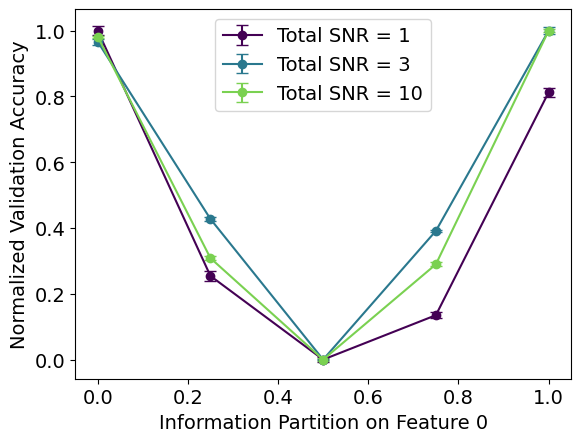

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Calcolo le medie e le deviazioni standard (prima del reshape)
fixed_SNR_partition_mean = np.mean(accuracy_fixed_SNR_partition, axis=1)
fixed_SNR_partition_std = np.std(accuracy_fixed_SNR_partition, axis=1)

# 2. Reshape dei dati per avere una riga per ogni curva (3 curve, 5 punti ciascuna)
accuracy_fixed_snr = np.reshape(fixed_SNR_partition_mean, (fixed_SNR_partition_mean.shape[0] // 5, 5))
err_accuracy_fixed_snr = np.reshape(fixed_SNR_partition_std, (fixed_SNR_partition_std.shape[0] // 5, 5))

labels = ["Total SNR = 1", "Total SNR = 3", "Total SNR = 10"]
x = np.linspace(0, 1, 5)

fig, ax = plt.subplots()

# 3. Recupero la colormap sequenziale di default delle heatmap ('viridis')
# Estraggo N colori equispaziati lungo la mappa in base al numero di curve
cmap = plt.get_cmap('viridis')
colors = cmap(np.linspace(0, 0.8, len(labels))) # Ci fermiamo a 0.8 per evitare il giallo troppo chiaro

for i, y in enumerate(accuracy_fixed_snr):
    accuracy_fixed_snr[i] = (accuracy_fixed_snr[i] - min(accuracy_fixed_snr[i]))/(max(accuracy_fixed_snr[i])-min(accuracy_fixed_snr[i]))
    err_accuracy_fixed_snr[i] /= (max(accuracy_fixed_snr[i])-min(accuracy_fixed_snr[i]))
# 4. Ciclo corretto con enumerate
for i, y in enumerate(accuracy_fixed_snr):
    ax.errorbar(
        x, 
        y, 
        yerr=err_accuracy_fixed_snr[i, :], 
        label=labels[i], 
        color=colors[i],
        fmt='-o',          # Aggiunge un pallino sui punti per leggerlo meglio
        capsize=4          # Aggiunge i "baffetti" orizzontali alle barre d'errore
    )

# Grafica di contorno opzionale per pulire il plot
ax.set_xlabel("Information Partition on Feature 0")
ax.set_ylabel("Normalized Validation Accuracy")
ax.legend()
plt.savefig("sist_error.png", bbox_inches="tight")

plt.show()